# EDA – FitLife Health & Fitness Tracking Dataset

Ce notebook explore le dataset **FitLife Health & Fitness Tracking** dans le cadre du projet TrAIn.me.

L’objectif est de vérifier la qualité des données (structure, typage, complétude) avant toute
modélisation prédictive.

## Objectif

Vérifier que le fichier `health_fitness_dataset.csv` est correctement chargé et obtenir une vue
d’ensemble :

- dimensions du jeu de données (nombre de lignes et de colonnes) ;
- typage des variables (numériques, catégorielles) ;
- première inspection des valeurs manquantes et des doublons ;
- cohérence générale du corpus avant analyse statistique détaillée.

## Interprétation attendue

À partir de cette première inspection, il s’agira de commenter :

- la taille globale du dataset (nombre de lignes / colonnes) ;
- la nature des variables (mélange de mesures numériques, indicateurs de santé et catégories) ;
- la présence éventuelle de valeurs manquantes et leur concentration sur certaines colonnes ;
- l’existence (ou non) de doublons dans les données brutes ;
- la cohérence générale des premières lignes (valeurs réalistes, formats attendus).

Cette interprétation sert de point de départ pour juger de la qualité du corpus et décider des
premières actions de nettoyage à mener dans les sections suivantes.


## Configuration notebook

### Importation des librairies essentielles

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from pathlib import Path
import sys

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
root = Path.cwd()  # ex : .../train.me/src/notebooks/eda/health_fitness_dataset
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence : il doit exister un dossier 'themes/' quelque part au-dessus."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📂 Contenu de", themes_root, ":", [x.name for x in themes_root.iterdir()])

from themes.theme_train_me import set_trainme_theme

✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📂 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Configuration d’affichage et thème TrAIn.me


In [2]:
# Options d’affichage pour les tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
USE_DARK_THEME = True  # bascule possible vers un thème clair si besoin

palette_trainme = set_trainme_theme(
    context="talk",
    font_scale=1.05,
    use_dark=USE_DARK_THEME
)

palette_trainme


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Activation du thème TrAIn.me

In [3]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


## Chargement et inspection initiale

#### Chargement du dataset `health_fitness_dataset.csv`


In [4]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("jijagallery/fitlife-health-and-fitness-tracking-dataset")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


Fichiers trouvés : ['health_fitness_dataset.csv']
Dataset chargé avec succès !
Dimensions : 687701 lignes et 22 colonnes



#### Aperçu des premières lignes


In [5]:
df.head(10)


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,103,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,102,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,126,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,141,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,112,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33
5,1,2024-01-10,56,F,165.3,54.9,HIIT,31,Medium,6.8,121,7.5,10,10202,2.2,19.6,69.5,110.7,72.9,NaN,Never,0.37
6,1,2024-01-11,56,F,165.3,55.2,Weight Training,97,High,12.4,145,6.6,8,5912,2.8,19.6,69.5,110.7,72.9,NaN,Never,0.51
7,1,2024-01-12,56,F,165.3,55.5,HIIT,70,Low,12.9,99,6.1,7,9477,1.6,19.6,69.5,110.7,72.9,NaN,Never,0.58
8,1,2024-01-17,56,F,165.3,55.7,HIIT,89,Medium,19.7,112,7.2,7,9710,3.3,19.6,69.5,110.7,72.9,NaN,Never,0.68
9,1,2024-01-18,56,F,165.3,56.0,Weight Training,115,Medium,12.8,117,5.6,3,7830,2.0,19.6,69.5,110.7,72.9,NaN,Never,0.82


#### Informations sur le typage, les valeurs manquantes et les doublons


In [6]:
# Typage et complétude globale
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  object 
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  object 
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   activity_type             687701 non-null  object 
 7   duration_minutes          687701 non-null  int64  
 8   intensity                 687701 non-null  object 
 9   calories_burned           687701 non-null  float64
 10  avg_heart_rate            687701 non-null  int64  
 11  hours_sleep               687701 non-null  float64
 12  stress_level              687701 non-null  int64  
 13  daily_steps               687701 non-null  i

### Statistiques descriptives des variables numériques

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
participant_id,687701.0,1499.781828,865.997215,1.00,749.00,1499.00,2249.00,3000.00
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
hours_sleep,687701.0,7.048799,0.972068,4.00,6.40,7.00,7.70,10.00
stress_level,687701.0,5.252389,2.770029,1.00,3.00,5.00,8.00,10.00
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00


### Analyse des valeurs manquantes et doublons

In [8]:
# Comptage des valeurs manquantes par colonne
missing_counts = df.isna().sum().sort_values(ascending=False)

print("\n🔎 Valeurs manquantes par colonne (top 20) :")
display(missing_counts.head(20))

# Comptage des doublons ligne à ligne
n_duplicates = df.duplicated().sum()
print(f"\n🧬 Nombre de doublons (lignes strictement identiques) : {n_duplicates}")


🔎 Valeurs manquantes par colonne (top 20) :


health_condition            490275
participant_id                   0
date                             0
smoking_status                   0
blood_pressure_diastolic         0
blood_pressure_systolic          0
resting_heart_rate               0
bmi                              0
hydration_level                  0
daily_steps                      0
stress_level                     0
hours_sleep                      0
avg_heart_rate                   0
calories_burned                  0
intensity                        0
duration_minutes                 0
activity_type                    0
weight_kg                        0
height_cm                        0
gender                           0
dtype: int64


🧬 Nombre de doublons (lignes strictement identiques) : 0


### Liste complète des colonnes disponibles

In [9]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())


--- Liste des colonnes du dataset ---
['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'health_condition', 'smoking_status', 'fitness_level']


## Statistiques descriptives et distribution des variables

### Objectif

Obtenir une vue d’ensemble chiffrée des variables du dataset :

- résumer la distribution des variables numériques (moyenne, médiane, min, max, quartiles) ;
- analyser la répartition des variables catégorielles (genres, types d’activités, intensité, etc.) ;
- repérer les ordres de grandeur, les asymétries et les éventuelles valeurs extrêmes ;
- préparer l’identification de patterns intéressants pour la modélisation.

### Interprétation attendue

À l’issue de cette étape, l’interprétation devra mettre en évidence :

- les valeurs centrales des variables clés (moyennes, médianes, étendue) pour caractériser le profil général des participants ;
- la dispersion et la variabilité des mesures (écarts-types, quartiles), permettant d’identifier des comportements hétérogènes ou des tendances majoritaires ;
- la présence éventuelle de valeurs extrêmes ou atypiques (poids très élevé, steps négatifs, calories inhabituellement hautes) qui pourront nécessiter un traitement spécifique ;
- la répartition des modalités des variables catégorielles (genre, types d’activités, intensité), révélant les comportements majoritaires ;
- les premières pistes d’analyse quant aux relations possibles entre activité physique, niveaux de stress, sommeil, hydratation et condition physique.

Cette interprétation servira de base pour orienter la suite de l’analyse, notamment l’identification des corrélations, la détection d’anomalies et la préparation des features pour la modélisation prédictive.


### Statistiques descriptives globales


In [10]:
# Statistiques descriptives de base
stats = df.describe().T
display(stats)

# Vérification des bornes extrêmes sur les principales métriques du dataset FitLife
print(f"Âge moyen : {df['age'].mean():.1f} ans")
print(f"Poids moyen : {df['weight_kg'].mean():.1f} kg")
print(f"Calories moyennes brûlées : {df['calories_burned'].mean():.0f} kcal")
print(f"IMC moyen : {df['bmi'].mean():.1f}")


,count,mean,std,min,25%,50%,75%,max
participant_id,687701.0,1499.781828,865.997215,1.00,749.00,1499.00,2249.00,3000.00
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
hours_sleep,687701.0,7.048799,0.972068,4.00,6.40,7.00,7.70,10.00
stress_level,687701.0,5.252389,2.770029,1.00,3.00,5.00,8.00,10.00
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00


Âge moyen : 41.7 ans
Poids moyen : 94.9 kg
Calories moyennes brûlées : 15 kcal
IMC moyen : 22.7


### Distribution des variables clés


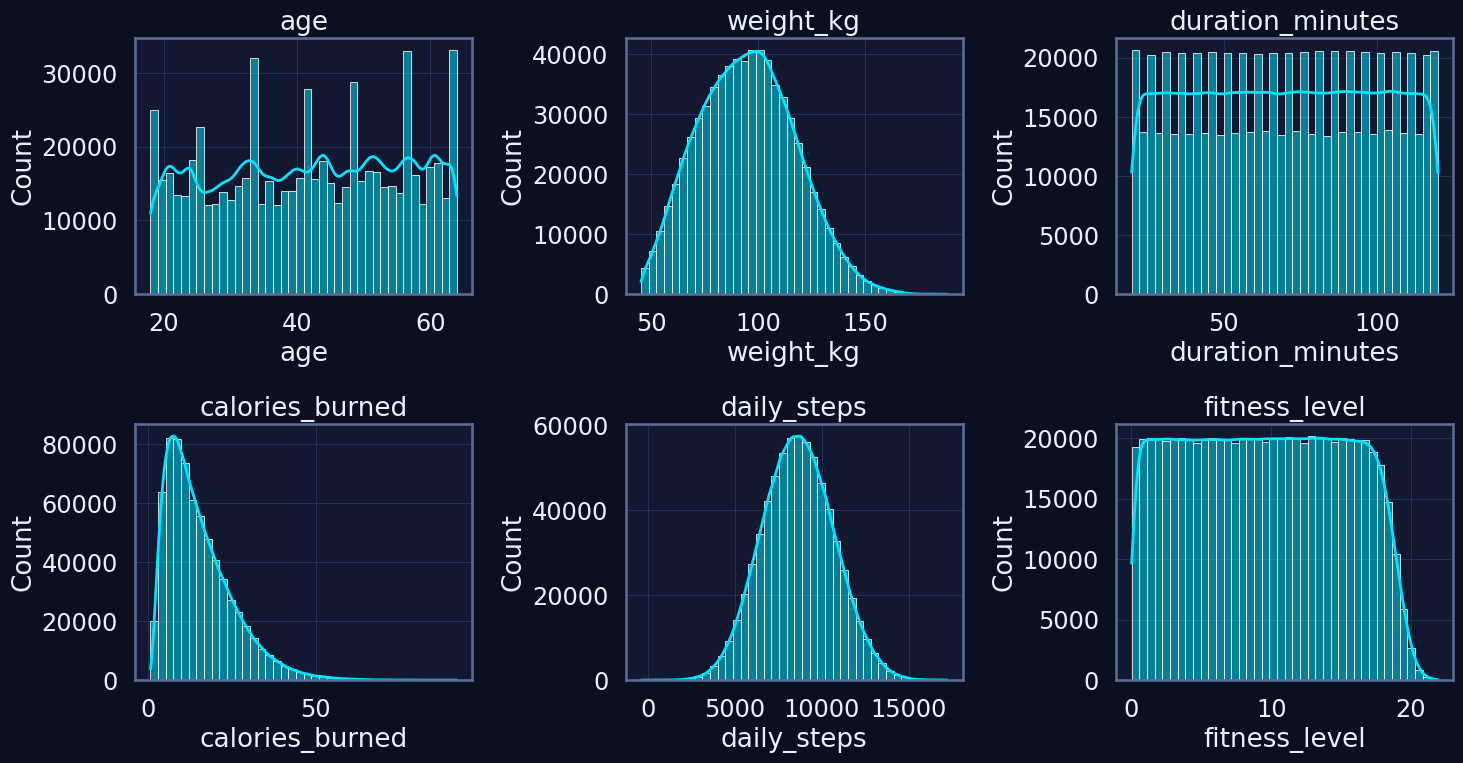

In [11]:
num_vars = [
    "age",
    "weight_kg",
    "duration_minutes",
    "calories_burned",
    "daily_steps",
    "fitness_level"
]

num_vars = [v for v in num_vars if v in df.columns]

n = len(num_vars)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(col)
    plt.grid(True)

plt.tight_layout()
plt.show()


### Boxplots pour repérer les outliers


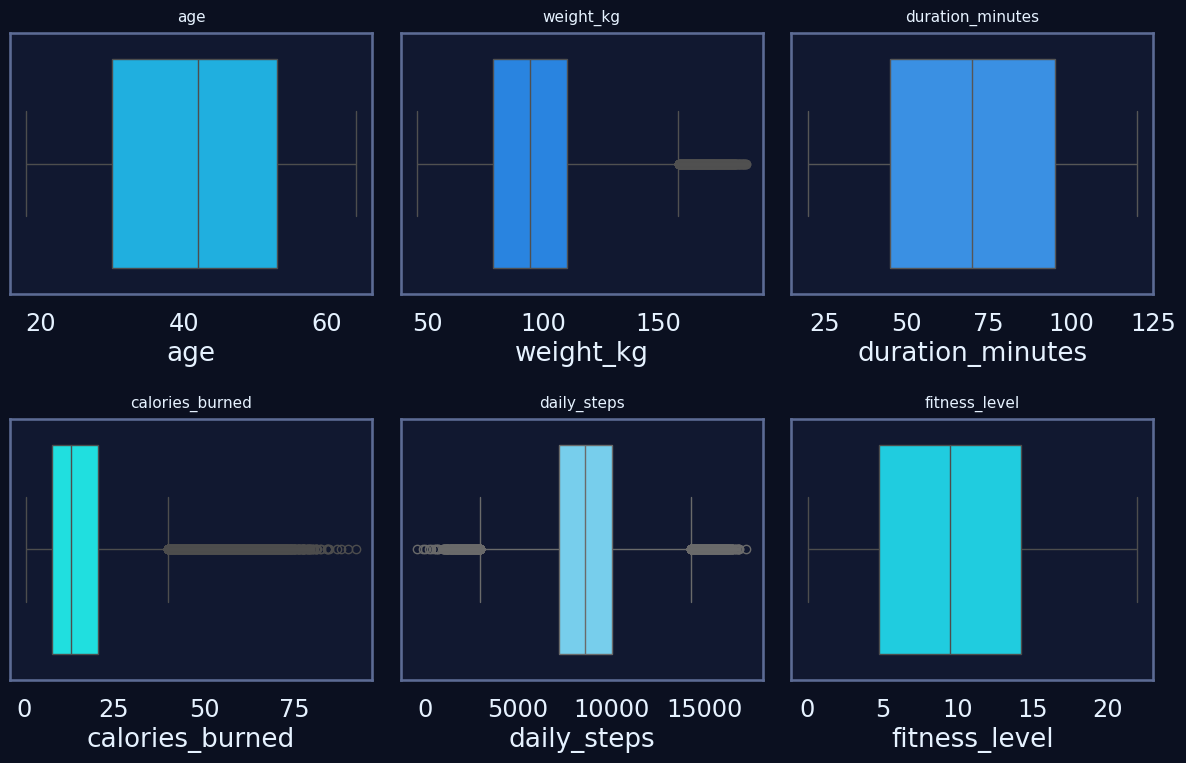

In [12]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)])
    plt.title(col, fontsize=11, pad=8)
plt.tight_layout()
plt.show()


### Statistiques descriptives enrichies


In [13]:
# --- Colonnes numériques (on exclut les colonnes dérivées à magnitude extrême) ---
num_cols = df.select_dtypes(include="number").columns.tolist()
to_exclude = ["Burns Calories (per 30 min)_bc"]  # valeurs ~1e19–1e20, non comparables
num_cols = [c for c in num_cols if c not in to_exclude]

print(f"{len(num_cols)} variables numériques analysées.")

desc = df[num_cols].describe().T
desc["missing_%"] = df[num_cols].isna().mean() * 100
desc["zeros_%"]   = (df[num_cols] == 0).mean() * 100
desc["skew"]      = df[num_cols].skew()
desc["kurt"]      = df[num_cols].kurt()

display(desc.sort_values("std", ascending=False).head(12))  # top 12 par variance


16 variables numériques analysées.


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00,0.0,0.0,0.062185,-0.155186
participant_id,687701.0,1499.781828,865.997215,1.00,749.00,1499.00,2249.00,3000.00,0.0,0.0,0.000852,-1.200757
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00,0.0,0.0,-0.001944,-1.199195
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40,0.0,0.0,0.191474,-0.378706
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00,0.0,0.0,0.360952,-0.234441
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00,0.0,0.0,-0.063646,-1.193656
blood_pressure_systolic,687701.0,120.001260,10.008917,78.00,113.10,120.20,127.00,152.70,0.0,0.0,-0.072306,0.008349
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00,0.0,0.0,1.235929,1.891749
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50,0.0,0.0,0.179715,-0.435383
blood_pressure_diastolic,687701.0,80.188079,8.239418,53.70,74.60,80.10,85.70,112.10,0.0,0.0,0.132936,0.078316


### Détection rapide d’outliers (IQR)


In [14]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])
iqr_df.sort_values("outliers", ascending=False).head(15)


,outliers
calories_burned,17441
blood_pressure_diastolic,6107
hours_sleep,5897
bmi,4147
resting_heart_rate,3738
blood_pressure_systolic,3602
daily_steps,3094
avg_heart_rate,1867
weight_kg,1706
height_cm,460


### Aperçu corrélations (sous-ensemble lisible)


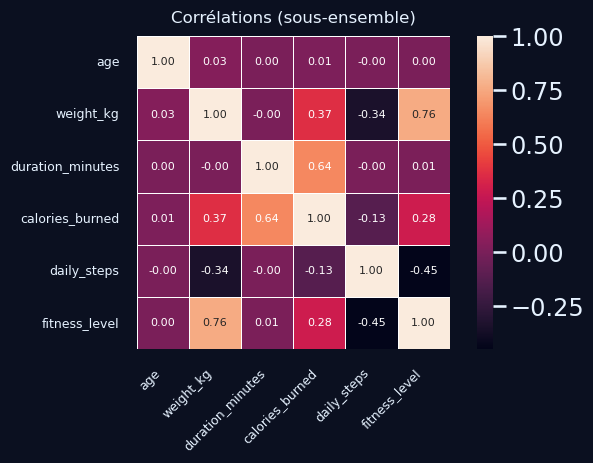

In [15]:
subset_cols = ["age", "weight_kg", "duration_minutes", "calories_burned", "daily_steps", "fitness_level"]
corr = df[subset_cols].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=True,
    annot_kws={"size": 8},    # 🔹 taille des annotations
    linewidths=0.5,           # optionnel : lignes fines entre les cases
)

plt.title("Corrélations (sous-ensemble)", fontsize=12, pad=10)
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()


## Visualisation univariée

### Objectif

L’objectif de cette section est de compléter les statistiques descriptives par une analyse
visuelle des distributions :

- observer la forme des distributions (symétrie, asymétrie, aplatissement) ;
- repérer les valeurs extrêmes ou atypiques visibles sur les graphiques ;
- identifier les variables présentant des comportements particuliers (effet de seuil, plafond, etc.) ;
- préparer les décisions de nettoyage et de transformation (normalisation, winsorisation, log-scale…).


### Interprétation attendue

À l’issue de cette étape, l’interprétation devra :

- décrire les grandes tendances des distributions (centrées, étalées, asymétriques, multimodales) ;
- signaler les variables possédant des queues longues ou des concentrations de valeurs extrêmes ;
- distinguer les variables “propres” (distributions régulières) des variables nécessitant un traitement
  spécifique avant la modélisation ;
- mettre en évidence les variables les plus informatives pour caractériser les profils utilisateurs
  (ex. durée des séances, nombre de pas, niveau de forme, stress, sommeil).

Ces éléments guideront la stratégie de nettoyage et de préparation des features.


### Visualisation des distributions univariées


Variables numériques visualisées (15) : ['age', 'height_cm', 'weight_kg', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level']


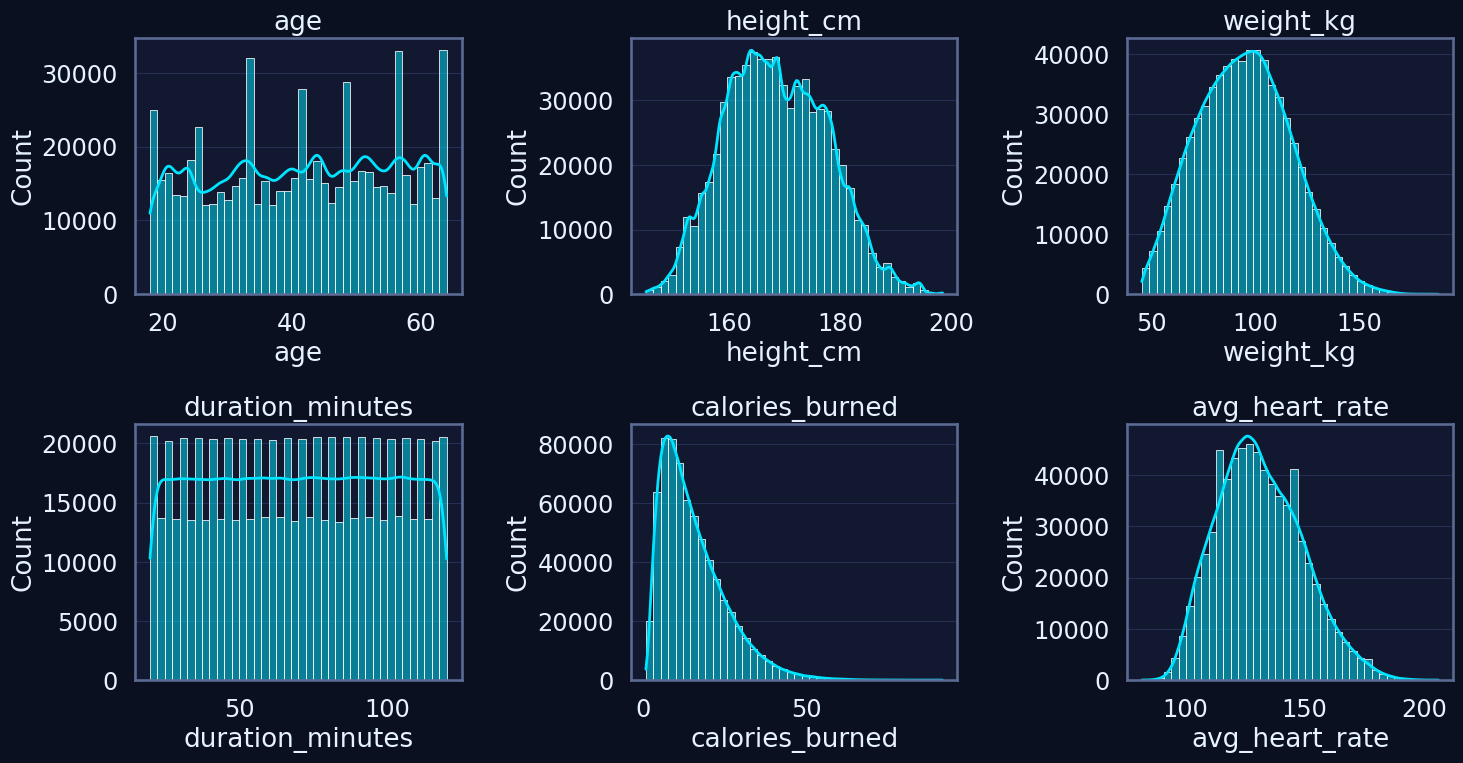

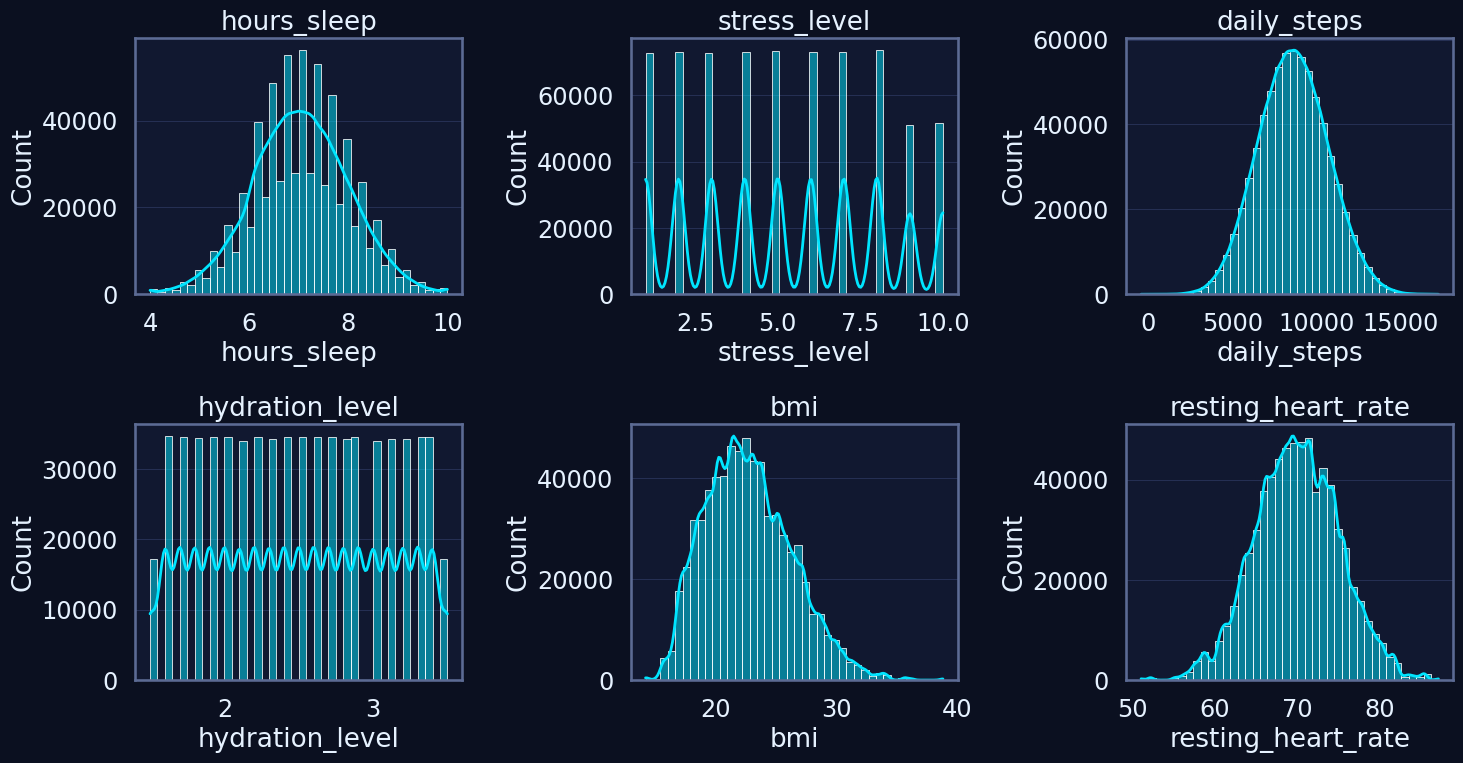

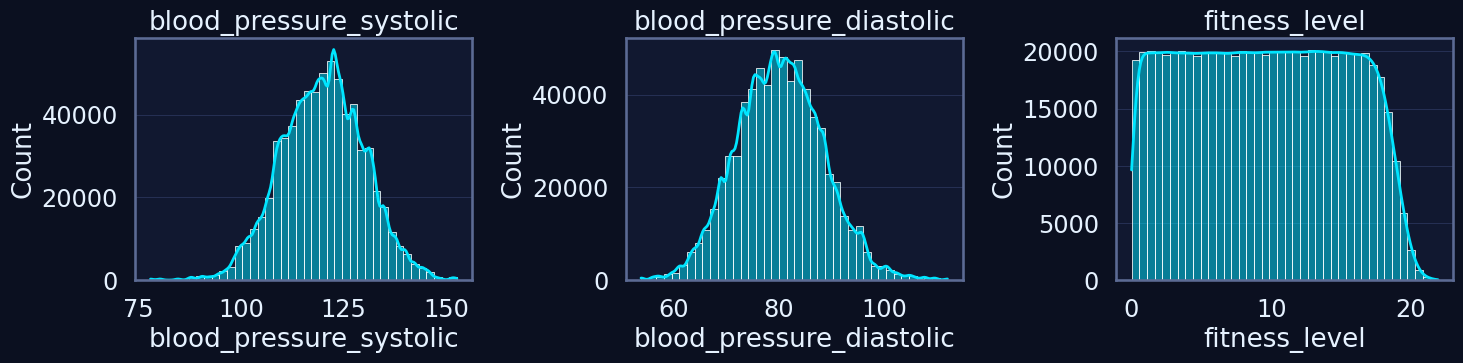

In [16]:
# Sélection des variables numériques à visualiser
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# On retire les identifiants techniques qui n'ont pas d'intérêt de distribution métier
cols_exclude = ["participant_id"]
num_to_plot = [c for c in num_cols if c not in cols_exclude]

print(f"Variables numériques visualisées ({len(num_to_plot)}) : {num_to_plot}")

# Affichage par paquets pour garder des figures lisibles
n_cols = 3
batch_size = n_cols * 2  # 2 lignes par figure

for i in range(0, len(num_to_plot), batch_size):
    batch = num_to_plot[i : i + batch_size]
    n = len(batch)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for j, col in enumerate(batch, start=1):
        plt.subplot(n_rows, n_cols, j)
        sns.histplot(df[col], bins=40, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots univariés pour détection visuelle d'outliers


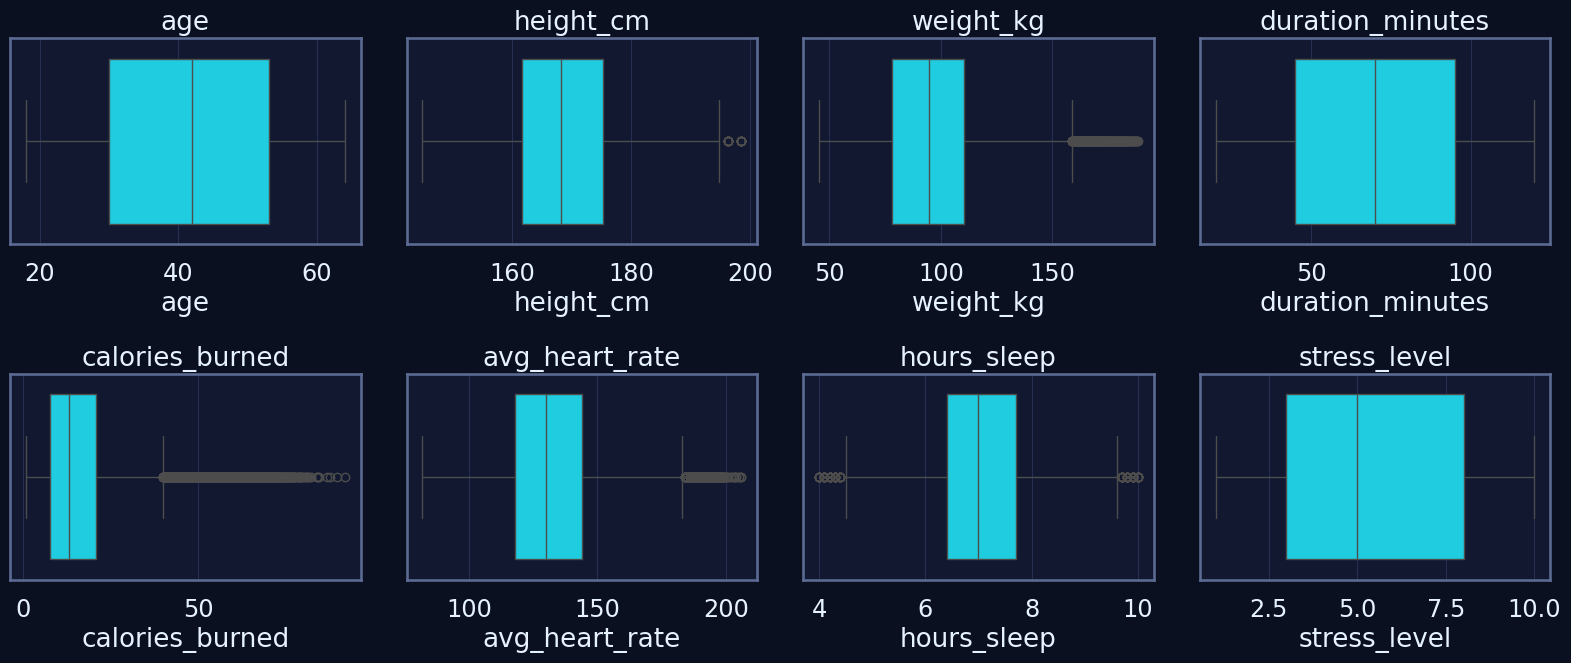

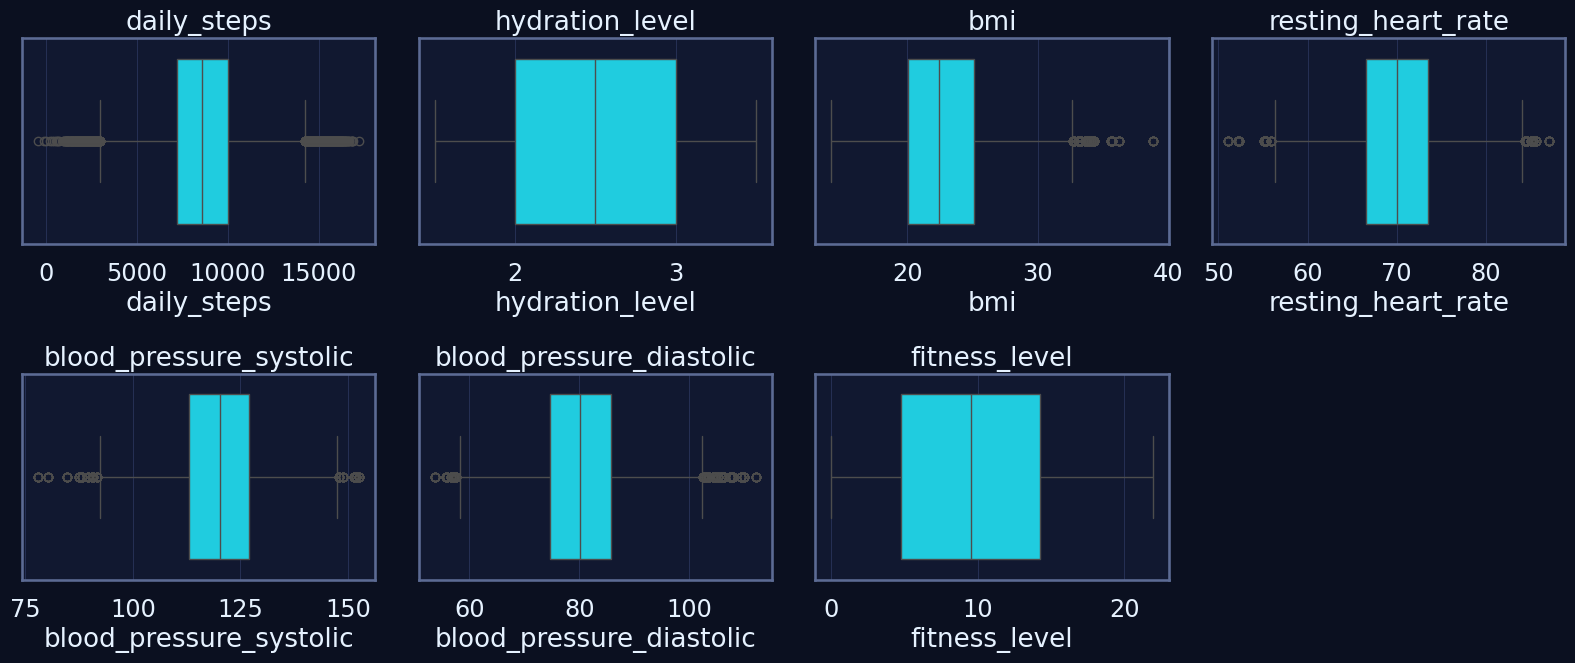

In [17]:
# Même sous-ensemble que pour les histogrammes
num_to_plot = [c for c in num_cols if c not in cols_exclude]

n_cols = 4
batch_size = n_cols * 2  # 2 lignes par figure

for i in range(0, len(num_to_plot), batch_size):
    batch = num_to_plot[i : i + batch_size]
    n = len(batch)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

    for j, col in enumerate(batch, start=1):
        plt.subplot(n_rows, n_cols, j)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()


## 3.3.4. Visualisation bivariée


### Objectif

Étudier les relations entre deux variables à la fois afin d’identifier :

- des corrélations linéaires ou non linéaires entre indicateurs de santé et d’activité ;
- des patterns comportementaux (ex. durée de séance ↔ calories brûlées, sommeil ↔ niveau de stress) ;
- des dépendances entre variables physiologiques (IMC, fréquence cardiaque, pression artérielle) et niveau de forme globale.

Ces visualisations serviront de base pour repérer les couples de variables les plus pertinents pour la modélisation du projet TrAIn.me.


### Interprétation attendue

À l’issue de cette section, l’interprétation devra mettre en évidence :

- la relation entre **durée des séances**, **volume d’activité** (daily_steps) et **calories brûlées** ;
- l’influence de la **morphologie** (BMI, poids) sur la dépense énergétique ;
- les liens entre **sommeil**, **stress** et **fitness_level**, en particulier l’impact potentiel d’un bon sommeil sur la condition physique ;
- le rôle de l’**hydratation** comme facteur de performance (calories_burned, fitness_level) ;
- la présence éventuelle de comportements atypiques (profils très actifs mais peu en forme, ou inversement).

Ces observations guideront la suite de l’analyse multivariée et la sélection des features pour les futurs modèles prédictifs TrAIn.me.


### Relations physiologiques et comportementales

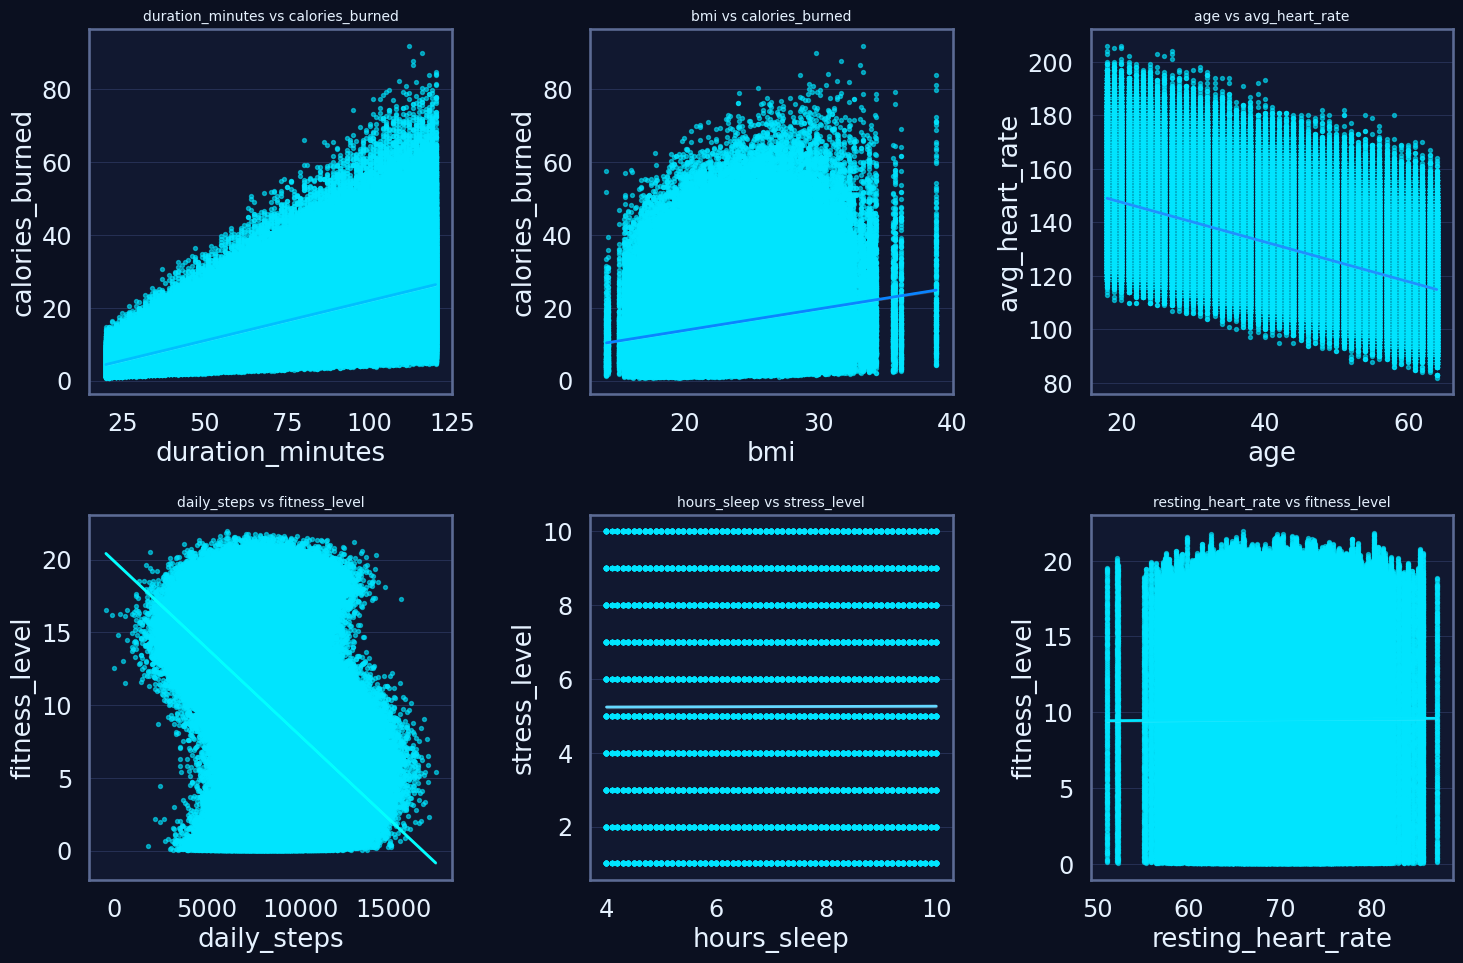

In [18]:
biv_pairs = [
    ("duration_minutes", "calories_burned"),
    ("bmi", "calories_burned"),
    ("age", "avg_heart_rate"),
    ("daily_steps", "fitness_level"),
    ("hours_sleep", "stress_level"),
    ("resting_heart_rate", "fitness_level"),
]

plt.figure(figsize=(15, 10))
for i, (x, y) in enumerate(biv_pairs, 1):
    ax = plt.subplot(2, 3, i)
    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={"s": 8, "alpha": 0.6},
        line_kws={
            "color": palette_trainme[i % len(palette_trainme)],
            "lw": 2,
        },
    )
    ax.set_title(f"{x} vs {y}", fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()


### Corrélation nutrition ↔ performance (hydratation & récupération)

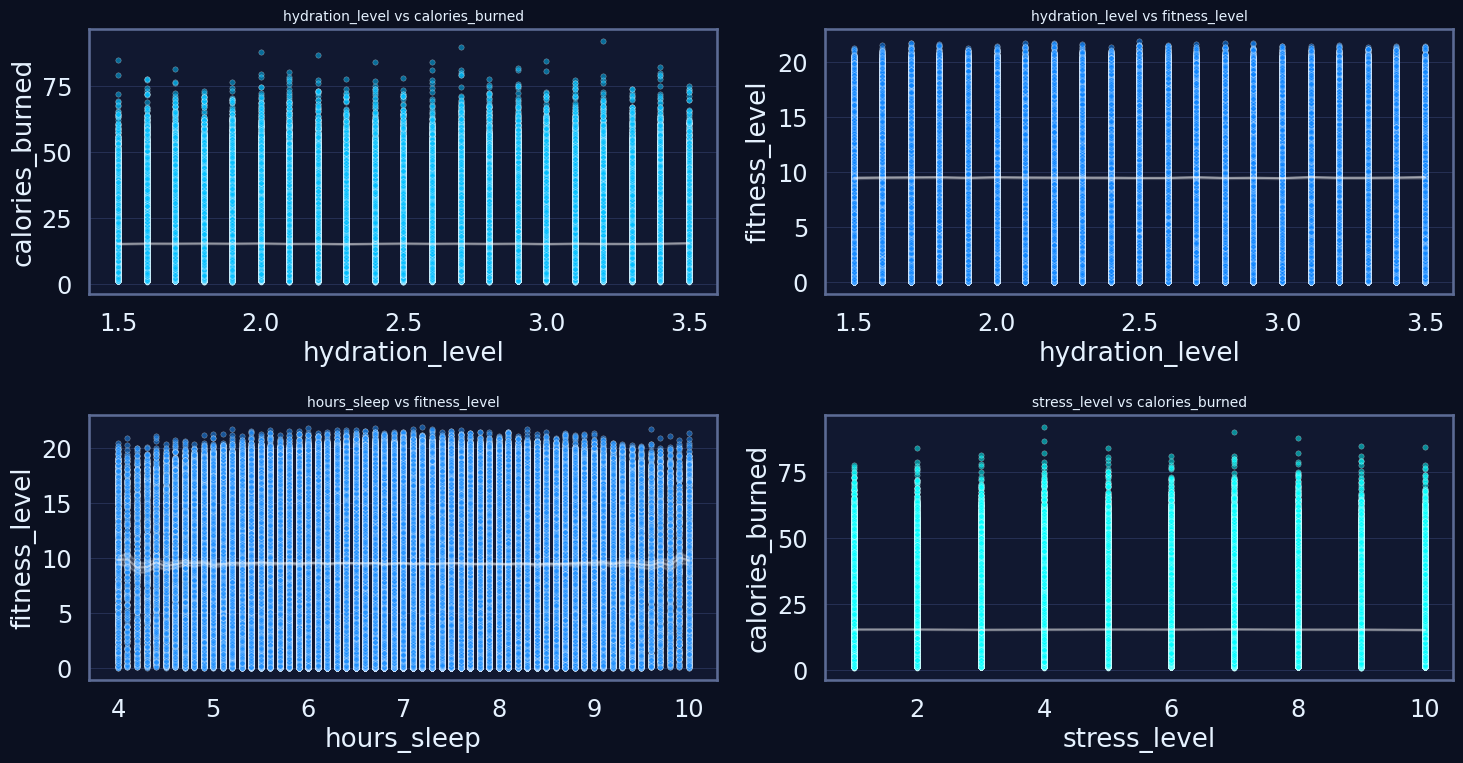

In [19]:
biv_pairs2 = [
    ("hydration_level", "calories_burned"),
    ("hydration_level", "fitness_level"),
    ("hours_sleep", "fitness_level"),
    ("stress_level", "calories_burned"),
]

plt.figure(figsize=(15, 8))
for i, (x, y) in enumerate(biv_pairs2, 1):
    ax = plt.subplot(2, 2, i)
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        color=palette_trainme[i % len(palette_trainme)],
        alpha=0.5,
        s=15,
    )
    sns.lineplot(
        data=df.sort_values(x),
        x=x,
        y=y,
        color="white",
        lw=1.5,
        alpha=0.4,
    )
    ax.set_title(f"{x} vs {y}", fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()
